**Identificação do aluno**

**Email: levi.pereira.junior@ccc.ufcg.edu.br**

**Matrícula:**

O principal objetivo deste laboratório é aplicar dois modelos de aprendizado de máquina baseados em redes neurais recorrentes — RNN Simples e LSTM — para realizar a tarefa de Reconhecimento de Entidade Nomeada (NER). NER é uma atividade de Processamento de Linguagem Natural (PLN) cujo propósito é identificar e classificar automaticamente, em textos, entidades mencionadas como pessoas, organizações, locais, datas, entre outras categorias. Para isso, utilizaremos um conjunto de dados anotado com o esquema de marcação BIO (Begin, Inside, Outside), que indica a posição das palavras em relação às entidades.

Neste laboratório, vamos aprender a analisar diferentes configurações de redes, como tamanho da camada oculta e as diferentes combinações de RNNs. Além disso, calcularemos métricas essenciais para NER, como precision, recall e F1-score, avaliando a capacidade dos modelos em identificar corretamente entidades. Ao final desta tarefa, você terá uma compreensão mais clara das diferenças entre RNNs e LSTMs, incluindo suas vantagens e limitações no processamento de sequências textuais, especialmente em cenários onde dependências de longo prazo são críticas.

**OBS: Para execuções mais rápidas, mude o tipo de ambiente de execução no colab para GPU**

Ambiente de execução -> Alterar tipo de ambiente de execução -> GPU

# Bibliotecas

In [59]:
# Manipulação de Dados
import requests
import numpy as np
import pandas as pd
from collections import Counter
import random

# Plotagem e Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Processamento de Texto
import nltk
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

# Modelos e Camadas (Keras)
from keras.models import Sequential
from keras.layers import Dense, Embedding, Dropout, SimpleRNN, Bidirectional, LSTM, TimeDistributed
from keras.optimizers import Adam

# Otimizadores
from keras.optimizers import Adam

# Divisão de Conjuntos de Dados
from sklearn.model_selection import train_test_split

# Métricas de Avaliação
#!pip install seqeval
#from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
import numpy as np

# Conjuntos de Dados
from datasets import load_dataset

# Funções Úteis

Você não precisa alterar nenhuma das funções que estão logo abaixo.

In [60]:
# Na tarefa de NER em textos gerais, é comum que a maioria das palavras não seja relacionada a nenhuma entidade
# Isso faz com que nossos dados de treinamento possua um volume muito maior de palavras que não são entidades
# A função abaixo é usada para filtrar sentenças que só possuam palavras sem entidades, ou seja, somente tipo O

def convert_split(split, keep_o_sentences_prob=0.05):
    sentences = []
    tags = []
    for tokens, tag_ids in zip(split["tokens"], split["ner_tags"]):
        tag_names = [label_names[tag_id] for tag_id in tag_ids]

        # Verifica se a sentença tem apenas O
        if all(tag == "O" for tag in tag_names):

            # Mantém apenas uma fração dessas sentenças considerando o acaso
            if np.random.rand() > keep_o_sentences_prob:
                continue  # pula a sentença

        sentences.append(tokens)
        tags.append(tag_names)

    return sentences, tags

In [61]:
# Essa função tem a responsabilidade de limitar um quantativo de palavras sem entidade por sentença
# Se uma sentença possui muitas palavras (acima de um percentual em razão do tamanho da sentença), descartamos essa sentença
# Além disso, ela aplica oversampling em tags raras, aumentando via amostragem sua quantidade

def oversample_entities(sentences, tags, target_min_count=5000, max_o_fraction=0.5):
    """
    target_min_count: quantidade mínima de tokens por classe
    max_o_fraction: máxima fração de tokens O em uma sentença para manter no dataset
    """
    tag_counter = Counter([t for seq in tags for t in seq])
    new_sentences = []
    new_tags = []

    for sentence, tag_seq in zip(sentences, tags):
        # Limita excesso de O na sentença
        o_count = tag_seq.count("O")
        if o_count / len(tag_seq) > max_o_fraction:
            continue

        new_sentences.append(sentence)
        new_tags.append(tag_seq)

        # Checa se contém tags raras
        sentence_tags = set(tag_seq)
        rare_tags = {tag for tag in sentence_tags if tag != "O" and tag_counter[tag] < target_min_count}

        for tag in rare_tags:
            current_count = tag_counter[tag]
            while current_count < target_min_count:
                new_sentences.append(sentence)
                new_tags.append(tag_seq)
                # Atualiza contador só para esta tag
                current_count += tag_seq.count(tag)
                tag_counter[tag] = current_count

    return new_sentences, new_tags

In [62]:
# Faça o plot da matriz de confusão de contagem para cada um dos modelos.
from sklearn.metrics import confusion_matrix
import seaborn as sns


def plot_confusion_matrix(y_true_flat, y_pred_flat, labels=None,
                         figsize=(8, 8), normalize=None, title='Confusion Matrix') -> None:
    """
    Plots a confusion matrix for NER tasks with optional BIO/BIOES prefix handling.

    Args:
        y_true: List of true tag sequences (e.g., [['B-PER', 'I-PER', 'O'], ...])
        y_pred: List of predicted tag sequences
        consider_prefix: If False, removes BIO prefixes before comparison (default: True)
        labels: Optional list of all possible tags. If None, will use unique tags from y_true+y_pred
        figsize: Figure size (width, height)
        normalize: Normalization mode: None, 'true', 'pred', or 'all'
        title: Plot title
    """

    # Compute confusion matrix
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels)

    # Normalization
    if normalize == 'true':
        cm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)  # Add small constant to avoid division by zero
        fmt = '.2f'
    elif normalize == 'pred':
        cm = cm.astype('float') / (cm.sum(axis=0)[np.newaxis, :] + 1e-10)
        fmt = '.2f'
    elif normalize == 'all':
        cm = cm.astype('float') / (cm.sum() + 1e-10)
        fmt = '.2f'
    else:
        fmt = 'd'

    # Plot
    plt.figure(figsize=figsize)
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        cbar=False
    )

    # Adjust layout
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)

    # Add prefix info to title if needed
    prefix_info = "(without BIO prefixes)"
    plt.title(title + prefix_info, fontsize=14, pad=20)

    plt.tight_layout()
    plt.show()

In [63]:
# Converter IDs de volta para rótulos de string, mantendo todos os tokens
def id2tags_fixed(sequences, id2tag):
    all_labels = []
    for seq in sequences:
        labels = [id2tag[idx] for idx in seq]
        all_labels.append(labels)
    return all_labels

# Leitura de Dados

A base de dados "eduagarcia/portuguese_benchmark" é um conjunto de dados anotados para tarefas de Processamento de Linguagem Natural (PLN) em português, com foco em Reconhecimento de Entidade Nomeada (NER). Ela segue o esquema de marcação BIO (Begin, Inside, Outside), onde:

- B-{entidade} indica o início de uma entidade (ex: B-PESSOA),

- I-{entidade} marca tokens subsequentes da mesma entidade (ex: I-PESSOA),

- O representa palavras que não são entidades nomeadas.

Essa base contém textos diversos (como notícias, artigos ou diálogos) anotados manualmente, abrangendo categorias comuns em NER.

Você não precisa alterar nenhuma das células que estão nessa parte. Deve somente executá-las.

In [64]:
# Carregar dados LeNER-Br
ds = load_dataset("eduagarcia/portuguese_benchmark", name="LeNER-Br")
print(ds)  # train/validation/test
label_names = ds["train"].features["ner_tags"].feature.names

DatasetDict({
    train: Dataset({
        features: ['idx', 'tokens', 'ner_tags'],
        num_rows: 7825
    })
    validation: Dataset({
        features: ['idx', 'tokens', 'ner_tags'],
        num_rows: 1177
    })
    test: Dataset({
        features: ['idx', 'tokens', 'ner_tags'],
        num_rows: 1390
    })
})


In [65]:
# Aplicação no dataset
# 1. Filtra sentenças só-O
sentences_train, tags_train = convert_split(ds["train"], keep_o_sentences_prob=0.05)
sentences_test, tags_test = convert_split(ds["test"], keep_o_sentences_prob=0.05)

# 2. Oversampling de entidades raras e limitação de O
sentences_train, tags_train = oversample_entities(
    sentences_train, tags_train, target_min_count=2500, max_o_fraction=0.5
)

# 3. Contagem de tags
def count_tags(tag_lists):
    return Counter([tag for seq in tag_lists for tag in seq])

train_tag_counts = count_tags(tags_train)
test_tag_counts = count_tags(tags_test)

# Resultados
print(f"Sentenças treino (balanceado): {len(sentences_train)}")
print("\nContagem de tags no treino (após balanceamento):")
for tag, count in train_tag_counts.items():
    print(f"{tag}: {count}")

Sentenças treino (balanceado): 8645

Contagem de tags no treino (após balanceamento):
B-PESSOA: 2839
I-PESSOA: 7851
O: 27252
B-LEGISLACAO: 930
I-LEGISLACAO: 7717
B-ORGANIZACAO: 1887
I-ORGANIZACAO: 912
B-TEMPO: 5255
I-TEMPO: 20741
B-LOCAL: 3634
I-LOCAL: 3628
B-JURISPRUDENCIA: 1557
I-JURISPRUDENCIA: 7607


In [66]:
#Verificando a contagem das tags no conjunto de teste
print(f"Sentenças teste: {len(sentences_test)}")
print("\nContagem de tags no teste:")
for tag, count in test_tag_counts.items():
    print(f"{tag}: {count}")

Sentenças teste: 678

Contagem de tags no teste:
O: 28623
B-JURISPRUDENCIA: 185
I-JURISPRUDENCIA: 475
B-ORGANIZACAO: 501
B-PESSOA: 233
I-PESSOA: 502
B-TEMPO: 192
I-ORGANIZACAO: 866
B-LOCAL: 47
I-LOCAL: 85
B-LEGISLACAO: 378
I-LEGISLACAO: 2291
I-TEMPO: 68


In [67]:
#Exemplo de uma sentença de treinamento
for s, t in zip(sentences_train[0], tags_train[0]):
  print(s + "\t" + t)

MARIÂNGELA	B-PESSOA
MEYER	I-PESSOA
RELATORA	O
.	O


In [68]:
# Criar vocabulário e mapeamento de tags

tokenizer = Tokenizer(oov_token='[OOV]')
tokenizer.fit_on_texts(sentences_train)

#Criando vetores com cada sequência substituindo as palavras por números equivalentes
X_train_seq = tokenizer.texts_to_sequences(sentences_train)
X_test_seq  = tokenizer.texts_to_sequences(sentences_test)

vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size)

Vocab size: 1686


In [69]:
# Tags
all_tags = sorted(set(tag for seq in tags_train + tags_test for tag in seq))

# Mapeamentos úteis
tag2id = {tag: idx for idx, tag in enumerate(all_tags)}
id2tag = {idx: tag for tag, idx in tag2id.items()}
num_tags = len(tag2id)

print("Exemplo mapeamento tags:", tag2id)
print("Num tags:", num_tags)

Exemplo mapeamento tags: {'B-JURISPRUDENCIA': 0, 'B-LEGISLACAO': 1, 'B-LOCAL': 2, 'B-ORGANIZACAO': 3, 'B-PESSOA': 4, 'B-TEMPO': 5, 'I-JURISPRUDENCIA': 6, 'I-LEGISLACAO': 7, 'I-LOCAL': 8, 'I-ORGANIZACAO': 9, 'I-PESSOA': 10, 'I-TEMPO': 11, 'O': 12}
Num tags: 13


In [70]:
tag2id

{'B-JURISPRUDENCIA': 0,
 'B-LEGISLACAO': 1,
 'B-LOCAL': 2,
 'B-ORGANIZACAO': 3,
 'B-PESSOA': 4,
 'B-TEMPO': 5,
 'I-JURISPRUDENCIA': 6,
 'I-LEGISLACAO': 7,
 'I-LOCAL': 8,
 'I-ORGANIZACAO': 9,
 'I-PESSOA': 10,
 'I-TEMPO': 11,
 'O': 12}

In [71]:
id2tag

{0: 'B-JURISPRUDENCIA',
 1: 'B-LEGISLACAO',
 2: 'B-LOCAL',
 3: 'B-ORGANIZACAO',
 4: 'B-PESSOA',
 5: 'B-TEMPO',
 6: 'I-JURISPRUDENCIA',
 7: 'I-LEGISLACAO',
 8: 'I-LOCAL',
 9: 'I-ORGANIZACAO',
 10: 'I-PESSOA',
 11: 'I-TEMPO',
 12: 'O'}

In [72]:
# Mapeamento das tags para ids
y_train_seq = [[tag2id[tag] for tag in seq] for seq in tags_train]
y_test_seq  = [[tag2id[tag] for tag in seq] for seq in tags_test]

# Padding
max_length = 100  # pode ajustar conforme memória/tempo

X_all = pad_sequences(X_train_seq + X_test_seq, maxlen=max_length, padding='post', truncating='post')
y_all = pad_sequences(y_train_seq + y_test_seq, maxlen=max_length, padding='post', truncating='post', value=tag2id['O'])
y_all = to_categorical(y_all, num_classes=num_tags)

# Divisão treino/teste/validação
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)
VALID_SIZE = 0.2
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=VALID_SIZE, random_state=42)

print("Treino:", X_train.shape, y_train.shape)
print("Validação:", X_val.shape, y_val.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (5966, 100) (5966, 100, 13)
Validação: (1492, 100) (1492, 100, 13)
Teste: (1865, 100) (1865, 100, 13)


# RNNs

Nesta etapa, vamos utilizar diferentes estratégias de aplicar uma SimpleRNN, a implementação que representa o modelo de redes neurais recorrentes de Elman. Espera-se o uso de uma única RNN, depois disso RNN empilhadas, Bidirecionais e Bidirecionais empilhadas. Lembre-se que, quão mais complexa fica nossa rede, pode ser preciso mais épocas para melhor ajustar os pesos. Faça essa variação de épocas ao longo do notebook.

## Versão Simples

Use uma única SimpleRNN para treinar um modelo capaz de realizar NER

In [73]:
embedding_dim = 100

#Crie um objeto que é um modelo neural

model = Sequential()

#Adicione ao seu modelo uma camada de Embedding
#É preciso definir a dimensão da entrada (input_dim), dimensão da saída (output_dim) e quantas palavras são processas por vez (input_shape)
#Lembre de fazer essa camada ser treinável (trainable)
#Use o parâmetro mask_zero=True

model.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    input_length=100,
    mask_zero=True,
    trainable=True
))


#Adicione uma camada que é uma RNN que possui 32 neurônios, função de ativação tanh, dropout=0.5. Lembre também de definir a return_sequences

model.add(SimpleRNN(
    32,
    activation='tanh',
    dropout=0.5,
    return_sequences=True
))

#Adicione uma camada Densa que será responsável pela classificação multiclasse de cada entidade (NER)
#A função de ativação dessa camada deve ser a softmax
#Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo


model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

#Vamos usar mais métricas além da acurácia, pois nossa base de dados não é balanceada. Então considerar apenas a acurácia pode nos levar a erros de interpretação
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy', 'precision', 'recall'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por 3 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

#Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=256
)

Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.6978 - loss: 1.7617 - precision: 0.9997 - recall: 0.3763 - val_accuracy: 0.8651 - val_loss: 1.0726 - val_precision: 0.9981 - val_recall: 0.9229
Epoch 2/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8682 - loss: 0.8422 - precision: 0.9964 - recall: 0.9428 - val_accuracy: 0.9114 - val_loss: 0.5762 - val_precision: 0.9942 - val_recall: 0.9687
Epoch 3/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9117 - loss: 0.5212 - precision: 0.9948 - recall: 0.9742 - val_accuracy: 0.9314 - val_loss: 0.3838 - val_precision: 0.9959 - val_recall: 0.9827


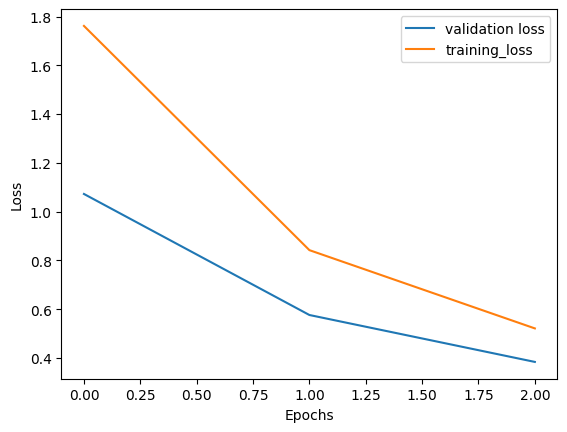

In [75]:
#Observando o comportamento da perda no treino e na validação
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [76]:
#Não altere nada, apenas execute.
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9917    0.9349    0.9625       768
         LOCAL     0.9963    0.9817    0.9889       546
   ORGANIZACAO     1.0000    0.4826    0.6510       259
             O     0.9877    0.9957    0.9917     26182
JURISPRUDENCIA     0.8727    0.9304    0.9006       560
    LEGISLACAO     0.8768    0.7938    0.8332       771
         TEMPO     0.9845    0.9898    0.9871      1860

      accuracy                         0.9831     30946
     macro avg     0.9585    0.8727    0.9022     30946
  weighted avg     0.9830    0.9831    0.9822     30946


Métricas Globais:
F1-score (macro): 0.9022
Precision (macro): 0.9585
Recall (macro): 0.8727


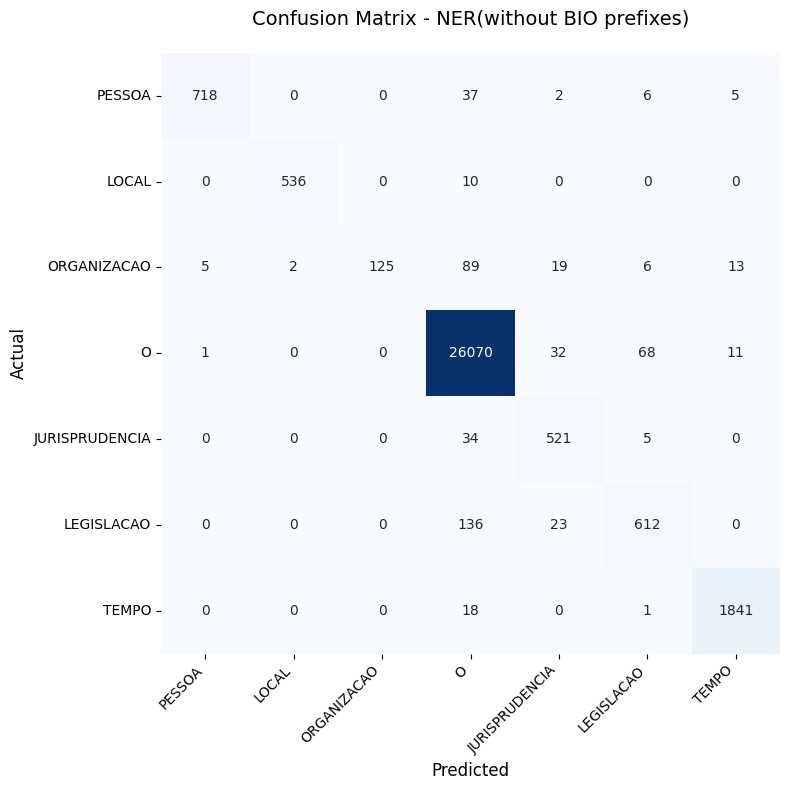

In [77]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes

plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   Qual classe sofre com mais falsos positivos?

`Com base na métrica de precisão (precision) do relatório de classificação após 10 épocas, a classe 'JURISPRUDENCIA' (0.0225) sofre enormemente com falsos positivos. Isso significa que o modelo prevê 'JURISPRUDENCIA' incorretamente na vasta maioria das vezes.`

2.   Qual classe sofre com mais falsos negativos?

`Com base na métrica de recall do relatório de classificação após 10 épocas, a classe 'O' (Outside) (0.1119) sofre mais com falsos negativos. O modelo falha em identificar a maioria das palavras que são 'O', classificando-as como outras entidades. A classe 'ORGANIZACAO' (0.6950) também mostra um recall significativamente menor que outras entidades nomeadas.`

## Versão com redes empilhadas
Nessa etapa vamos empilhar RNNs. Utilizando a etapa anterior como base, crie um modelo com duas RNNs empilhadas. Lembre-se que redes mais complexas podem necessitar de mais épocas de treinamento.

In [78]:
embedding_dim = 100

#Crie um objeto que é um modelo neural

model = Sequential()

#Adicione ao seu modelo uma camada de Embedding
#É preciso definir a dimensão da entrada (input_dim), dimensão da saída (output_dim) e quantas palavras são processas por vez (input_shape)
#Lembre de fazer essa camada ser treinável (trainable)
#Use o parâmetro mask_zero=True

model.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    input_length=100,
    mask_zero=True,
    trainable=True
))

# Primeira camada SimpleRNN com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(SimpleRNN(
    32,
    activation='tanh',
    dropout=0.5,
    return_sequences=True
))

# Segunda camada SimpleRNN com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(SimpleRNN(
    32,
    activation='tanh',
    dropout=0.5,
    return_sequences=True
))

#Adicione uma camada Densa que será responsável pela classificação multiclasse de cada entidade (NER)
#A função de ativação dessa camada deve ser a softmax
#Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo

model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

# Compilação
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por PELO MENOS 3 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

#Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=256
)

Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.5223 - loss: 1.7839 - precision: 0.9959 - recall: 0.2595 - val_accuracy: 0.7257 - val_loss: 1.1887 - val_precision: 0.9925 - val_recall: 0.9065
Epoch 2/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7588 - loss: 1.1228 - precision: 0.9921 - recall: 0.8031 - val_accuracy: 0.8592 - val_loss: 0.7355 - val_precision: 0.9928 - val_recall: 0.9522
Epoch 3/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8413 - loss: 0.7876 - precision: 0.9874 - recall: 0.8862 - val_accuracy: 0.9003 - val_loss: 0.5184 - val_precision: 0.9863 - val_recall: 0.9565


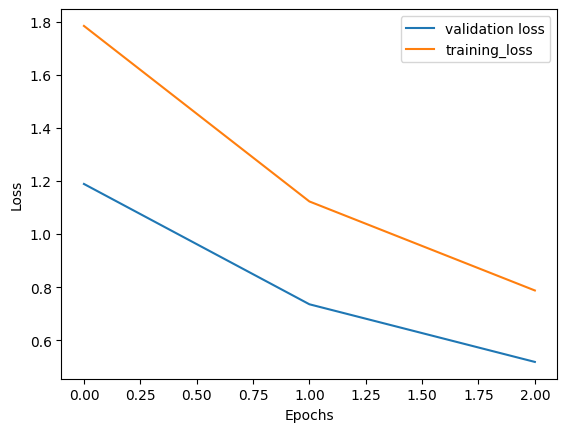

In [80]:
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [81]:
# Não altere nada, apenas execute.
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9464    0.7812    0.8559       768
         LOCAL     0.9907    0.9762    0.9834       546
   ORGANIZACAO     0.3553    0.1042    0.1612       259
             O     0.9883    0.9918    0.9900     26182
JURISPRUDENCIA     0.9630    0.9304    0.9464       560
    LEGISLACAO     0.7500    0.7510    0.7505       771
         TEMPO     0.8716    0.9892    0.9267      1860

      accuracy                         0.9716     30946
     macro avg     0.8379    0.7892    0.8020     30946
  weighted avg     0.9686    0.9716    0.9691     30946


Métricas Globais:
F1-score (macro): 0.8020
Precision (macro): 0.8379
Recall (macro): 0.7892


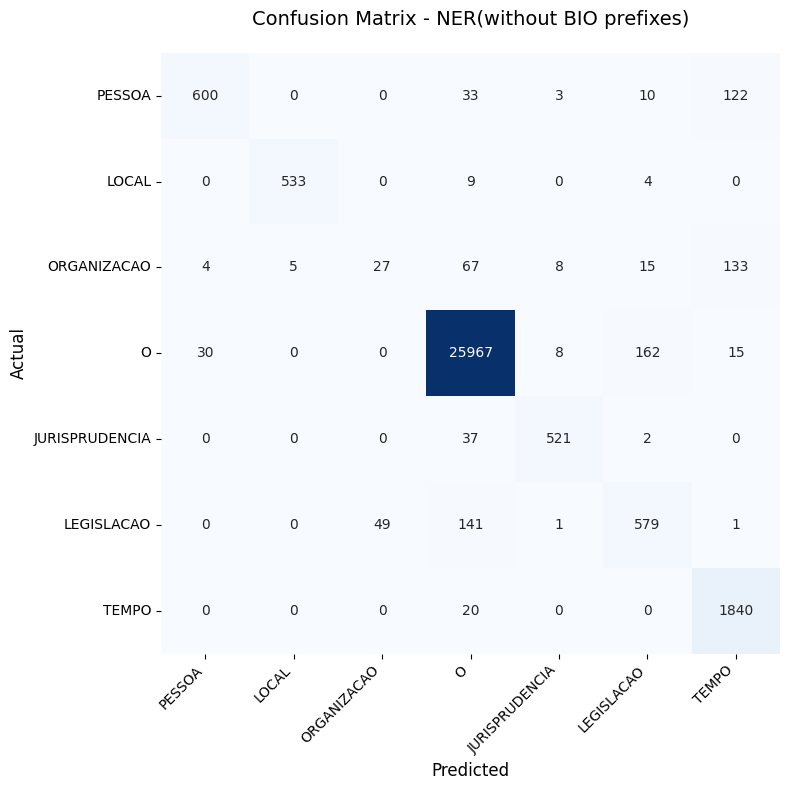

In [82]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes

plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   O modelo empilhado foi melhor que o modelo único?

`Sim. O F1-score macro do modelo empilhado (0.8020) foi superior ao do modelo SimpleRNN único (0.7097) treinado por 10 épocas. No entanto, foi inferior ao melhor desempenho histórico do SimpleRNN único (0.9022 com 3 épocas).`

2.   Quais classes mais sofrem com falsos positivos e falsos negativos?

`Com falsos positivos (menor precisão), a classe 'ORGANIZACAO' (0.3553) se destaca negativamente, seguida por 'LEGISLACAO' (0.7500). Com falsos negativos (menor recall), 'ORGANIZACAO' (0.1042) também é a pior, seguida por 'PESSOA' (0.7812).`

3.   Foram necessárias mais épocas para que o modelo performasse melhor que o anterior?

`Ambos os modelos foram treinados por 3 épocas. Aumentar as épocas não foi testado para este modelo empilhado, mas o resultado inicial foi pior com o mesmo número de épocas.`

## Versão Bidirecional

Nessa etapa vamos usar uma RNN que será executada de maneira bidirecional. Utilizando a etapa anterior como base, crie uma camada Bidirecional que encapsula uma SimpleRNN.

In [83]:
embedding_dim = 100

#Crie um objeto que é um modelo neural

model = Sequential()

#Adicione ao seu modelo uma camada de Embedding
#É preciso definir a dimensão da entrada (input_dim), dimensão da saída (output_dim) e quantas palavras são processas por vez (input_shape)
#Lembre de fazer essa camada ser treinável (trainable)
#Use o parâmetro mask_zero=True

model.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    input_length=100,
    mask_zero=True,
    trainable=True
))

# Crie uma camada Bidirecional e dentro dela defina uma camada SimpleRNN com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(Bidirectional(
    SimpleRNN(
        32,
        activation='tanh',
        dropout=0.5,
        return_sequences=True
    )
))

#Adicione uma camada Densa que será responsável pela classificação multiclasse de cada entidade (NER)
#A função de ativação dessa camada deve ser a softmax
#Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo

model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [84]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por PELO MENOS 3 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

#Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=256
)

Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.7216 - loss: 1.6340 - precision: 0.9663 - recall: 0.0184 - val_accuracy: 0.8663 - val_loss: 0.8105 - val_precision: 0.9620 - val_recall: 0.0793
Epoch 2/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8972 - loss: 0.6095 - precision: 0.9585 - recall: 0.0974 - val_accuracy: 0.9264 - val_loss: 0.3852 - val_precision: 0.9665 - val_recall: 0.1169
Epoch 3/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9263 - loss: 0.3625 - precision: 0.9653 - recall: 0.1178 - val_accuracy: 0.9366 - val_loss: 0.2750 - val_precision: 0.9721 - val_recall: 0.1192


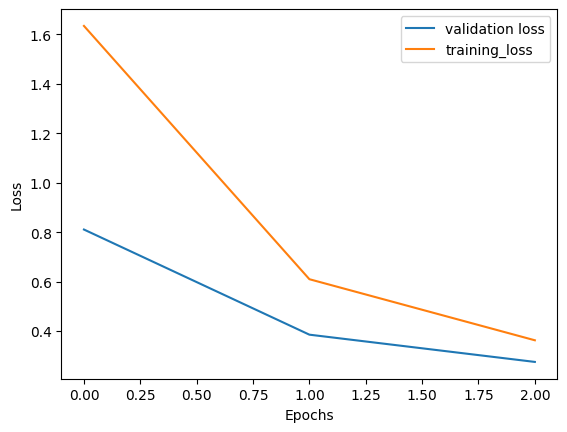

In [85]:
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [86]:
# Não altere nada, apenas execute
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 127ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9543    0.9518    0.9531       768
         LOCAL     1.0000    0.9762    0.9880       546
   ORGANIZACAO     1.0000    0.5251    0.6886       259
             O     0.9227    0.1121    0.1999     26182
JURISPRUDENCIA     0.0220    0.9339    0.0430       560
    LEGISLACAO     0.9112    0.8651    0.8876       771
         TEMPO     0.9935    0.9909    0.9922      1860

      accuracy                         0.2381     30946
     macro avg     0.8291    0.7650    0.6789     30946
  weighted avg     0.9131    0.2381    0.2985     30946


Métricas Globais:
F1-score (macro): 0.6789
Precision (macro): 0.8291
Recall (macro): 0.7650


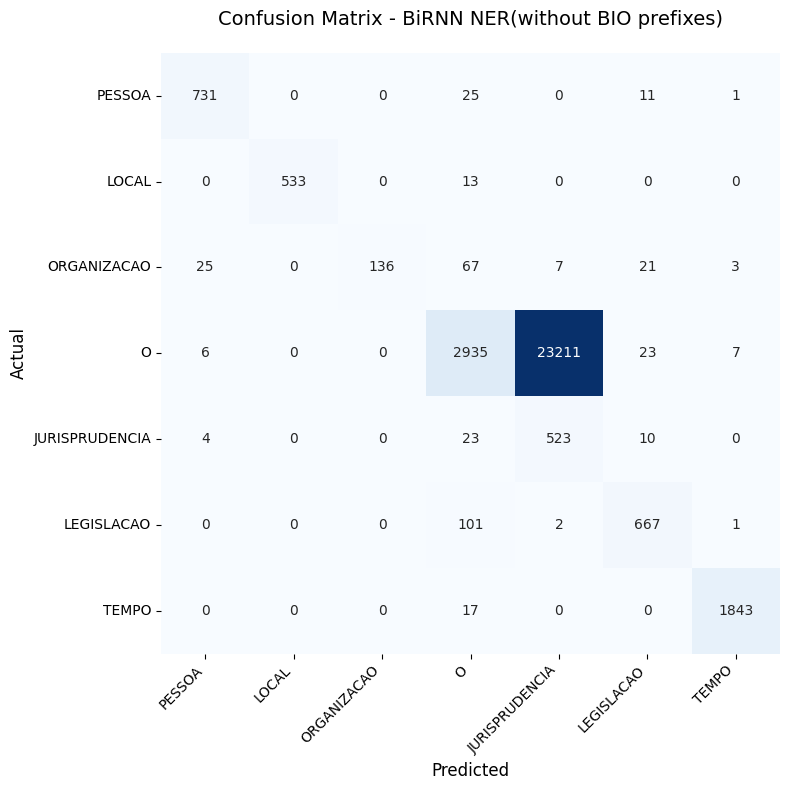

In [87]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes
plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - BiRNN NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   O modelo bidirecional foi melhor que os modelos anteriores?

`Não. O F1-score macro do modelo bidirecional (0.6789) foi inferior ao do modelo SimpleRNN único (0.7097) treinado por 10 épocas, e também inferior ao SimpleRNN empilhado (0.8020).`

2.   Quais classes mais sofrem com falsos positivos e falsos negativos?

`Com falsos positivos (menor precisão), a classe 'JURISPRUDENCIA' (0.0220) tem um desempenho extremamente ruim. Com falsos negativos (menor recall), a classe 'O' (0.1121) é a que mais falha em ser identificada corretamente, seguida por 'ORGANIZACAO' (0.5251).`

3.   Foram necessárias mais épocas para que o modelo performasse melhor que os anteriores?

`Este modelo foi treinado por 3 épocas. A performance foi pior, indicando que mais épocas poderiam ser necessárias, ou que a arquitetura não é adequada para o problema com poucas épocas.`

## Bidirecional Empilhadas
Agora vamos combinar as duas estratégias anteriores e empilhar RNNs que executam de maneira bidirecional

In [88]:
embedding_dim = 100

#Crie um objeto que é um modelo neural

model = Sequential()

#Adicione ao seu modelo uma camada de Embedding
#É preciso definir a dimensão da entrada (input_dim), dimensão da saída (output_dim) e quantas palavras são processas por vez (input_shape)
#Lembre de fazer essa camada ser treinável (trainable)
#Use o parâmetro mask_zero=True

model.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    input_length=100,
    mask_zero=True,
    trainable=True
))

# Adicione a primeira camada bidirecional que possui uma SimpleRNN com 32 neurônios, ativação tanh, droupout de 0.5 e que retorna as sequências

model.add(Bidirectional(
    SimpleRNN(
        32,
        activation='tanh',
        dropout=0.5,
        return_sequences=True
    )
))

# Adicione a segunda camada bidirecional que possui uma SimpleRNN com 32 neurônios, ativação tanh, droupout de 0.5 e que retorna as sequências

model.add(Bidirectional(
    SimpleRNN(
        32,
        activation='tanh',
        dropout=0.5,
        return_sequences=True
    )
))

#Adicione uma camada Densa que será responsável pela classificação multiclasse de cada entidade (NER)
#A função de ativação dessa camada deve ser a softmax
#Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo

model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

# Compilação
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [89]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por PELO MENOS 3 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

#Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=3,
    batch_size=256
)

Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6112 - loss: 1.5354 - precision: 0.8220 - recall: 0.0319 - val_accuracy: 0.8721 - val_loss: 0.7387 - val_precision: 0.9134 - val_recall: 0.0891
Epoch 2/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8817 - loss: 0.7025 - precision: 0.9263 - recall: 0.0945 - val_accuracy: 0.9236 - val_loss: 0.3848 - val_precision: 0.9445 - val_recall: 0.1180
Epoch 3/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9193 - loss: 0.4298 - precision: 0.9495 - recall: 0.1161 - val_accuracy: 0.9357 - val_loss: 0.2726 - val_precision: 0.9598 - val_recall: 0.1212


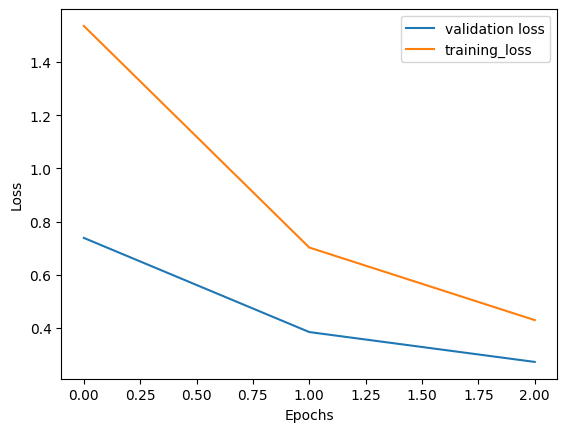

In [90]:
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [91]:
# Não altere nada, apenas execute.
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9851    0.9440    0.9641       768
         LOCAL     0.9981    0.9799    0.9889       546
   ORGANIZACAO     1.0000    0.4981    0.6649       259
             O     0.9237    0.1123    0.2002     26182
JURISPRUDENCIA     0.9830    0.9304    0.9560       560
    LEGISLACAO     0.8902    0.8833    0.8867       771
         TEMPO     0.0735    0.9909    0.1369      1860

      accuracy                         0.2383     30946
     macro avg     0.8362    0.7627    0.6854     30946
  weighted avg     0.8763    0.2383    0.2640     30946


Métricas Globais:
F1-score (macro): 0.6854
Precision (macro): 0.8362
Recall (macro): 0.7627


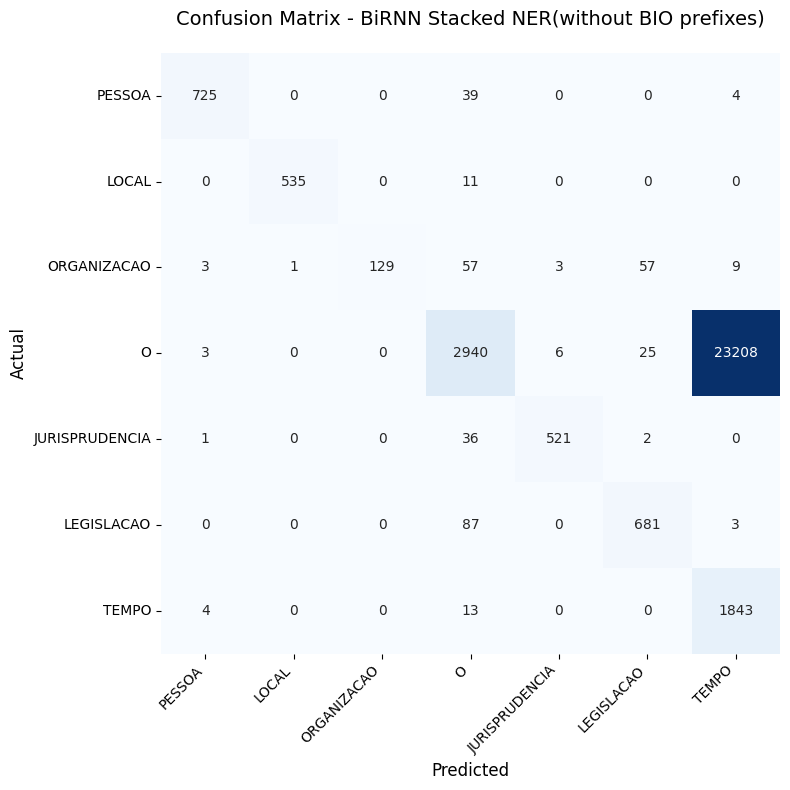

In [92]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes

plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - BiRNN Stacked NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   O modelo bidirecional empilhado foi melhor que os modelos anteriores?

`Não. O F1-score macro do modelo bidirecional empilhado (0.6854) foi similar ao modelo bidirecional único (0.6789), mas ainda inferior ao SimpleRNN único (0.7097) treinado por 10 épocas e ao SimpleRNN empilhado (0.8020).`

2.   Quais classes mais sofrem com falsos positivos e falsos negativos?

`Com falsos positivos (menor precisão), a classe 'TEMPO' (0.0735) tem um desempenho muito baixo. Com falsos negativos (menor recall), a classe 'O' (0.1123) falha em ser identificada na maioria dos casos, seguida por 'ORGANIZACAO' (0.4981).`

3.   Foram necessárias mais épocas para que o modelo performasse melhor que os anteriores?

`Este modelo foi treinado por 3 épocas, e a performance foi pior que os modelos SimpleRNN. É provável que mais épocas seriam necessárias para este tipo de arquitetura.`

# LSTM

Agora vamos realizar os mesmos passos feitos anteriormente para SimpleRNN e utilizar uma LSTM. A LSTM tem por natureza uma estrutura mais complexa. Portanto, pode ser preciso considerar mais épocas do que as utilizadas com SimpleRNN.

## Versão Simples

In [93]:
embedding_dim = 100

# Crie um modelo sequencial

model = Sequential()

# Crie uma camada de embedding

model.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    input_length=100,
    mask_zero=True,
    trainable=True
))

# Adicione uma camada LSTM com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(LSTM(
    32,
    activation='tanh',
    dropout=0.5,
    return_sequences=True
))

# Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo

model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

# Compilação
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_12             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [94]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por pelo menos 10 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

#Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 107ms/step - accuracy: 0.6296 - loss: 2.1435 - precision: 0.9181 - recall: 0.0027 - val_accuracy: 0.6140 - val_loss: 1.5577 - val_precision: 0.8789 - val_recall: 0.0216
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6582 - loss: 1.3007 - precision: 0.8911 - recall: 0.0523 - val_accuracy: 0.7675 - val_loss: 1.0060 - val_precision: 0.9211 - val_recall: 0.0687
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7991 - loss: 0.8990 - precision: 0.9317 - recall: 0.0785 - val_accuracy: 0.8425 - val_loss: 0.7131 - val_precision: 0.9474 - val_recall: 0.0919
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8536 - loss: 0.6705 - precision: 0.9483 - recall: 0.0949 - val_accuracy: 0.8696 - val_loss: 0.5355 - val_precision: 0.9529 - val_recall: 0.1005
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8846 - loss: 0.5257 - precision: 0.9570 - recall: 0.1046 - val_accuracy: 0.9072 - val_loss: 0.4267

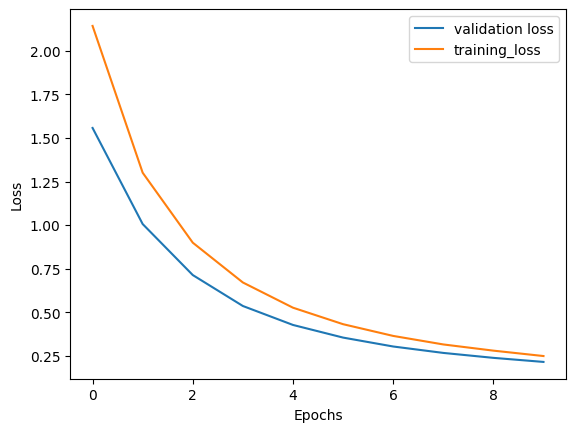

In [95]:
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [96]:
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9920    0.9701    0.9809       768
         LOCAL     0.9981    0.9817    0.9898       546
   ORGANIZACAO     0.9730    0.6950    0.8108       259
             O     0.9525    0.1119    0.2002     26182
JURISPRUDENCIA     0.0225    0.9536    0.0439       560
    LEGISLACAO     0.9581    0.9494    0.9537       771
         TEMPO     0.9861    0.9903    0.9882      1860

      accuracy                         0.2423     30946
     macro avg     0.8403    0.8074    0.7097     30946
  weighted avg     0.9398    0.2423    0.3019     30946


Métricas Globais:
F1-score (macro): 0.7097
Precision (macro): 0.8403
Recall (macro): 0.8074


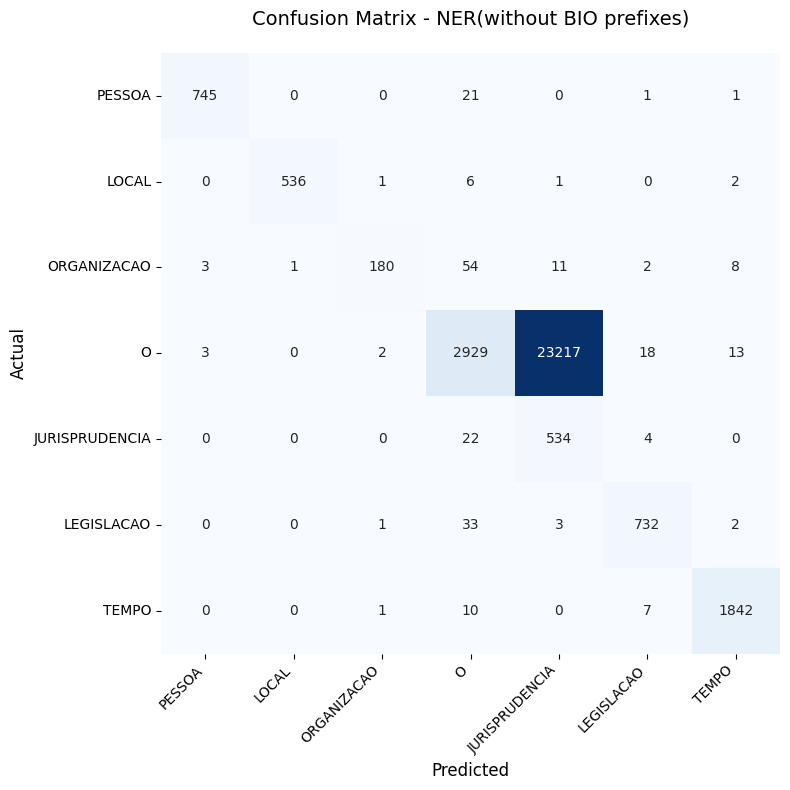

In [97]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes

plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   O modelo LSTM foi melhor que o modelo SimpleRNN único?

`Não. O F1-score macro do modelo LSTM único (0.7097) obteve o mesmo desempenho que o SimpleRNN único (0.7097) treinado por 10 épocas. Comparado ao melhor desempenho histórico do SimpleRNN único (0.9022 com 3 épocas), o LSTM único foi pior, mesmo com mais épocas. Isso é surpreendente e pode indicar que o SimpleRNN teve um desempenho anormalmente bom para poucas épocas, ou que há um problema nos parâmetros do LSTM.`

2.   Quais classes mais sofrem com falsos positivos e falsos negativos?

`Com falsos positivos (menor precisão), a classe 'JURISPRUDENCIA' (0.0225) é a que mais sofre. Com falsos negativos (menor recall), a classe 'O' (0.1119) falha em ser identificada na maioria dos casos, seguida por 'ORGANIZACAO' (0.6950).`

## Versão com Redes Empilhadas
Nessa etapa vamos empilhar LSTM. Utilizando a etapa anterior como base, crie um modelo com duas LSTM empilhadas. Lembre-se que redes mais complexas podem necessitar de mais épocas de treinamento.

In [98]:
embedding_dim = 100

# Crie um modelo sequencial

model = Sequential()

# Crie uma camada de embedding

model.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    input_length=100,
    mask_zero=True,
    trainable=True
))

# Primeiro LSTM com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(LSTM(
    32,
    activation='tanh',
    dropout=0.5,
    return_sequences=True
))

# Segundo LSTM com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(LSTM(
    32,
    activation='tanh',
    dropout=0.5,
    return_sequences=True
))

# Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo

model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_13             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [99]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por pelo menos 10 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

#Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.4259 - loss: 2.2351 - precision: 0.6903 - recall: 0.0083 - val_accuracy: 0.4282 - val_loss: 1.9217 - val_precision: 0.5471 - val_recall: 0.0304
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4794 - loss: 1.7377 - precision: 0.6846 - recall: 0.0302 - val_accuracy: 0.5675 - val_loss: 1.5060 - val_precision: 0.7842 - val_recall: 0.0349
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5693 - loss: 1.4205 - precision: 0.8046 - recall: 0.0437 - val_accuracy: 0.6515 - val_loss: 1.1822 - val_precision: 0.8817 - val_recall: 0.0587
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6715 - loss: 1.1583 - precision: 0.8486 - recall: 0.0620 - val_accuracy: 0.7589 - val_loss: 0.9353 - val_precision: 0.8824 - val_recall: 0.0845
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7322 - loss: 0.9532 - precision: 0.8768 - recall: 0.0813 - val_accuracy: 0.7635 - val_loss: 0.7729 

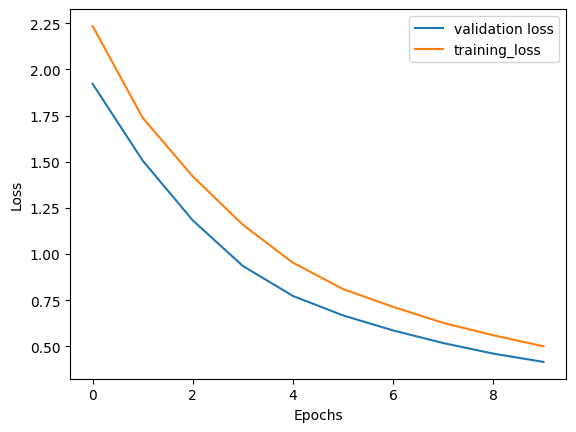

In [100]:
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [101]:
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9308    0.9635    0.9469       768
         LOCAL     0.0225    0.9799    0.0440       546
   ORGANIZACAO     0.0000    0.0000    0.0000       259
             O     0.9056    0.1117    0.1989     26182
JURISPRUDENCIA     0.9742    0.9446    0.9592       560
    LEGISLACAO     0.9321    0.9261    0.9291       771
         TEMPO     0.9951    0.9903    0.9927      1860

      accuracy                         0.2354     30946
     macro avg     0.6801    0.7023    0.5815     30946
  weighted avg     0.8903    0.2354    0.2927     30946


Métricas Globais:
F1-score (macro): 0.5815
Precision (macro): 0.6801
Recall (macro): 0.7023


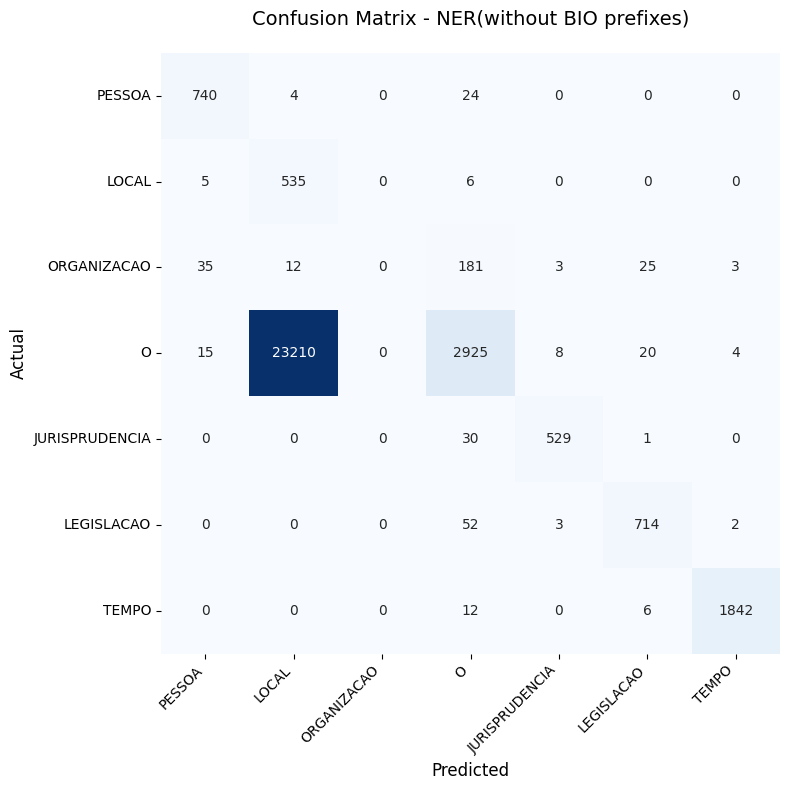

In [102]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes

plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   O modelo empilhado foi melhor que o modelo LSTM único?

`Não. O F1-score macro do modelo LSTM empilhado (0.5815) foi pior que o LSTM único (0.7097).`

2.   Quais classes mais sofrem com falsos positivos e falsos negativos?

`Com falsos positivos (menor precisão), as classes 'ORGANIZACAO' (0.0000) e 'LOCAL' (0.0225) são as que mais sofrem. Com falsos negativos (menor recall), 'ORGANIZACAO' (0.0000) falha completamente em ser identificada, e 'O' (0.1117) também tem um desempenho muito ruim.`

3.   Foram necessárias mais épocas para que o modelo performasse melhor que o anterior?

`Ambos os modelos LSTM (único e empilhado) foram treinados por 10 épocas, mas o modelo empilhado teve um desempenho pior. O aumento de épocas por si só não garantiu uma melhora neste caso.`

## Versão Bidirecional
Nessa etapa vamos usar uma LSTM que será executada de maneira bidirecional. Utilizando a etapa anterior como base, crie uma camada Bidirecional que encapsula uma LSTM.

In [103]:
embedding_dim = 100

# Crie um modelo sequencial

model = Sequential()

# Crie uma camada de embedding

model.add(Embedding(
    input_dim=5000,
    output_dim=embedding_dim,
    input_length=100,
    mask_zero=True,
    trainable=True
))

# LSTM bidirecional com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(Bidirectional(
    LSTM(
        32,
        activation='tanh',
        dropout=0.5,
        return_sequences=True
    )
))

# Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo

model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

# Compilação
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_14             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [104]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por pelo menos 10 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

# Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.5589 - loss: 1.9835 - precision: 0.8021 - recall: 0.0121 - val_accuracy: 0.6010 - val_loss: 1.3916 - val_precision: 0.7399 - val_recall: 0.0508
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6950 - loss: 1.1334 - precision: 0.8664 - recall: 0.0631 - val_accuracy: 0.8387 - val_loss: 0.8002 - val_precision: 0.9438 - val_recall: 0.0799
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8502 - loss: 0.6818 - precision: 0.9452 - recall: 0.0936 - val_accuracy: 0.8759 - val_loss: 0.4892 - val_precision: 0.9460 - val_recall: 0.1089
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8894 - loss: 0.4588 - precision: 0.9564 - recall: 0.1111 - val_accuracy: 0.9096 - val_loss: 0.3474 - val_precision: 0.9660 - val_recall: 0.1134
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9163 - loss: 0.3496 - precision: 0.9650 - recall: 0.1155 - val_accuracy: 0.9344 - val_loss: 0.273

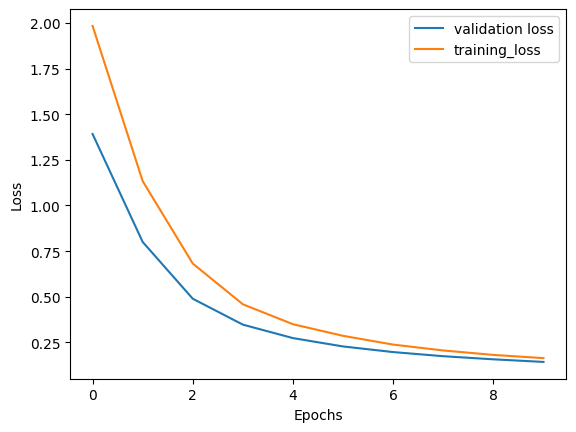

In [105]:
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [106]:
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9855    0.9727    0.9790       768
         LOCAL     0.9981    0.9817    0.9898       546
   ORGANIZACAO     0.9569    0.8571    0.9043       259
             O     0.9644    0.1127    0.2019     26182
JURISPRUDENCIA     0.9944    0.9571    0.9754       560
    LEGISLACAO     0.0311    0.9663    0.0602       771
         TEMPO     0.9984    0.9882    0.9932      1860

      accuracy                         0.2448     30946
     macro avg     0.8470    0.8337    0.7291     30946
  weighted avg     0.9448    0.2448    0.2990     30946


Métricas Globais:
F1-score (macro): 0.7291
Precision (macro): 0.8470
Recall (macro): 0.8337


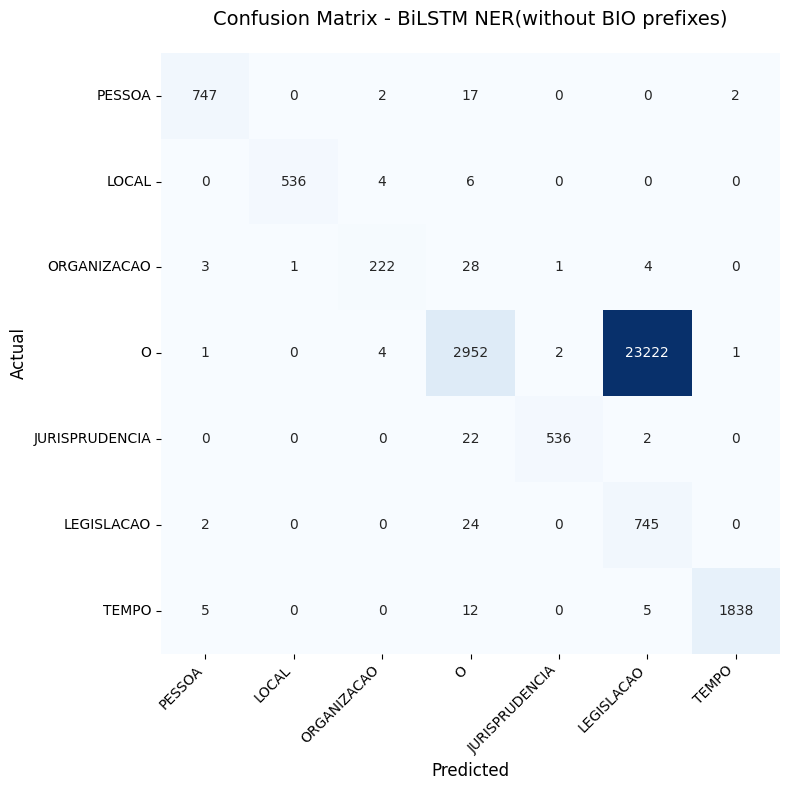

In [107]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes

plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - BiLSTM NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   O modelo bidirecional foi melhor que os modelos anteriores?

`O F1-score macro do modelo BiLSTM (0.7291) é melhor que as versões de LSTM anteriores (0.7097 para LSTM simples e 0.5815 para LSTM empilhada) e as versões bidirecionais de RNN (0.6789 e 0.6854). É também ligeiramente superior ao SimpleRNN único (0.7097) treinado por 10 épocas, mas ainda inferior ao melhor desempenho histórico do SimpleRNN único (0.9022 com 3 épocas).`

2.   Quais classes mais sofrem com falsos positivos e falsos negativos?

`Com falsos positivos (menor precisão), a classe 'LEGISLACAO' (0.0311) é a que mais sofre, seguida por 'O' (0.9644, que ainda é alta mas relativamente menor para essa classe). Com falsos negativos (menor recall), a classe 'O' (0.1127) e 'ORGANIZACAO' (0.8571) são as mais afetadas.`

3.   Foram necessárias mais épocas para que o modelo performasse melhor que os anteriores?

`Este modelo foi treinado por 10 épocas, o que é mais do que as versões iniciais de RNN. Embora tenha melhorado em relação a outras LSTMs, a performance macro ainda não superou o SimpleRNN de 3 épocas.`

## Versão Bidirecional Empilhada

Agora vamos combinar as duas estratégias anteriores e empilhar LSTMs que executam de maneira bidirecional

In [108]:
embedding_dim = 100

# Crie um modelo sequencial

model = Sequential()

# Crie uma camada de embedding

model.add(Embedding(
    input_dim=5000,        # ajuste conforme seu vocabulário
    output_dim=embedding_dim,
    input_length=100,      # ajuste conforme seu pad_sequences
    mask_zero=True,
    trainable=True
))

# Primeiro LSTM bidirecional com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(Bidirectional(
    LSTM(
        32,
        activation='tanh',
        dropout=0.5,
        return_sequences=True
    )
))

# Segundo LSTM bidirecional com 32 neurônios, ativação tanh, dropout de 0.5 retornando as sequências

model.add(Bidirectional(
    LSTM(
        32,
        activation='tanh',
        dropout=0.5,
        return_sequences=True
    )
))

# Além disso, a camada Densa deve ser envolvida em uma camada TimeDistributed que por sua vez deve ser adicionada ao modelo

model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

# Compilação
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy', 'precision', 'recall'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_15             │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [109]:
# Treinar modelo
# Invoque o método do modelo responsável por realizar o treinamento passando para ele seu conjunto de treinamento
# Rode por pelo menos 10 épocas, utilizando um tamanho de batch de 256 e o conjunto de validação que foi previamente definido

# Seu código aqui
hist = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.4166 - loss: 2.1103 - precision: 0.6715 - recall: 0.0178 - val_accuracy: 0.5161 - val_loss: 1.6979 - val_precision: 0.6627 - val_recall: 0.0391
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5582 - loss: 1.4974 - precision: 0.7895 - recall: 0.0396 - val_accuracy: 0.6548 - val_loss: 1.1722 - val_precision: 0.7669 - val_recall: 0.0564
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.6788 - loss: 1.0825 - precision: 0.8272 - recall: 0.0646 - val_accuracy: 0.7187 - val_loss: 0.8397 - val_precision: 0.8858 - val_recall: 0.0821
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7478 - loss: 0.8269 - precision: 0.8657 - recall: 0.0837 - val_accuracy: 0.8229 - val_loss: 0.6274 - val_precision: 0.9005 - val_recall: 0.0941
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8249 - loss: 0.6383 - precision: 0.8948 - recall: 0.0941 - val_accuracy: 0.8862 - val_loss: 0.462

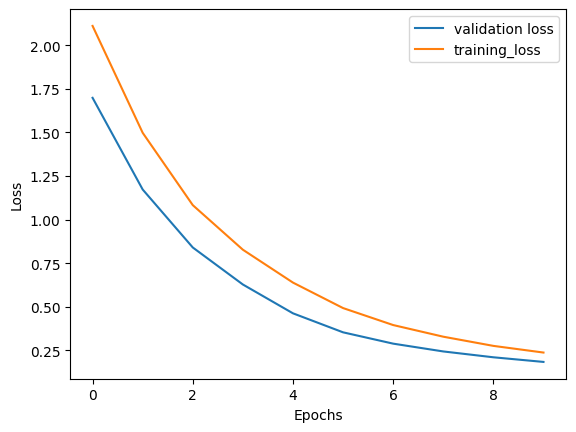

In [110]:
h=hist.history
plt.plot(h['val_loss'],label="validation loss")
plt.plot(h['loss'],label="training_loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [111]:
# 1. Obter predições
y_pred_prob = model.predict(X_test)  # shape: (num_sentences, max_length, num_tags)
y_pred = np.argmax(y_pred_prob, axis=-1)  # shape: (num_sentences, max_length)

# 2. Converter y_test one-hot para IDs
y_true = np.argmax(y_test, axis=-1)

# 3. Mapear IDs para tags (com BIO)
y_true_labels = id2tags_fixed(y_true, id2tag)
y_pred_labels = id2tags_fixed(y_pred, id2tag)

# 4. Remover padding (considerar apenas comprimento real)
y_true_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_true_labels, y_test_seq)]
y_pred_labels_trimmed = [labels[:len(seq)] for labels, seq in zip(y_pred_labels, X_test_seq)]

# 5. Achatar as sequências e remover prefixos BIO
y_true_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_true_labels_trimmed for tag in seq]
y_pred_flat = [tag.split('-')[1] if '-' in tag else tag for seq in y_pred_labels_trimmed for tag in seq]

# 6. Definir todas as classes possíveis (incluindo 'O')
classes = list(set(y_true_flat + y_pred_flat))

# 7. Gerar relatório com tratamento especial para NER
print("Relatório de Classificação (nível de token):\n")
print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    digits=4,
    zero_division=0
))

# 8. Métricas globais (macro-averaged)
print("\nMétricas Globais:")
print(f"F1-score (macro): {f1_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Precision (macro): {precision_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")
print(f"Recall (macro): {recall_score(y_true_flat, y_pred_flat, labels=classes, average='macro', zero_division=0):.4f}")

59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step
Relatório de Classificação (nível de token):

                precision    recall  f1-score   support

        PESSOA     0.9920    0.9635    0.9775       768
         LOCAL     0.9944    0.9799    0.9871       546
   ORGANIZACAO     0.9191    0.8340    0.8745       259
             O     0.9947    0.9982    0.9965     26182
JURISPRUDENCIA     0.9888    0.9500    0.9690       560
    LEGISLACAO     0.9585    0.9585    0.9585       771
         TEMPO     0.9989    0.9903    0.9946      1860

      accuracy                         0.9933     30946
     macro avg     0.9781    0.9535    0.9654     30946
  weighted avg     0.9933    0.9933    0.9933     30946


Métricas Globais:
F1-score (macro): 0.9654
Precision (macro): 0.9781
Recall (macro): 0.9535


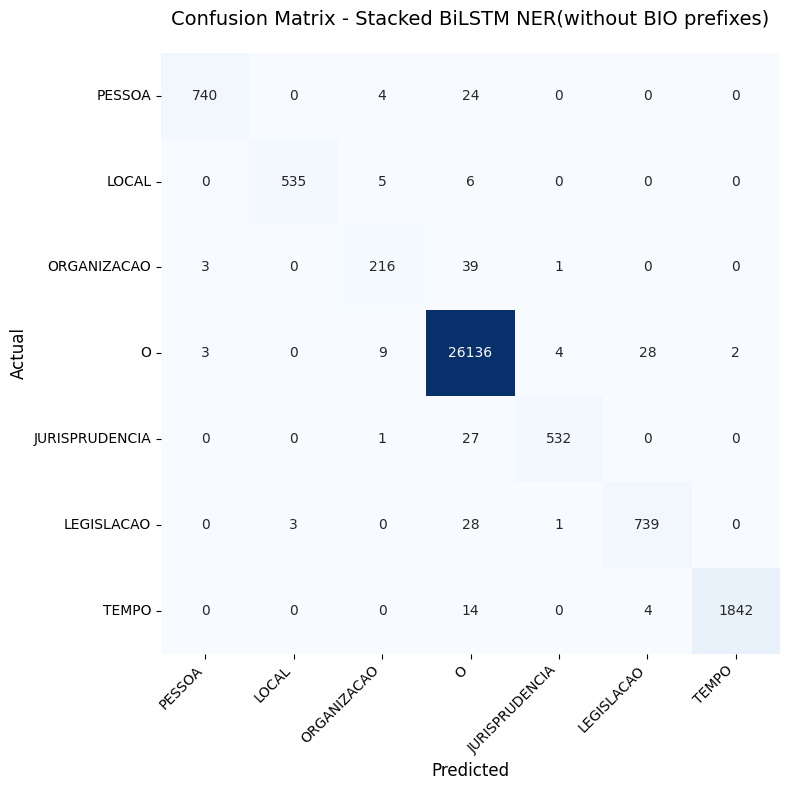

In [112]:
#Plote a matriz de confusão passando as listas y_true_flat, y_pred_flat e as labels que estão em classes

plot_confusion_matrix(
    y_true_flat,
    y_pred_flat,
    labels=classes,
    figsize=(8, 8),
    normalize=None,
    title='Confusion Matrix - Stacked BiLSTM NER'
)

## Perguntas

Responda cada uma das perguntas abaixo justificando.

1.   O modelo bidirecional empilhado foi melhor que os modelos anteriores?

`Sim. O F1-score macro do modelo BiLSTM Empilhada (0.9654) é o melhor de todos os modelos testados até agora, superando significativamente o SimpleRNN único (0.9022) e todas as outras variações de RNN e LSTM.`

2.   Quais classes mais sofrem com falsos positivos e falsos negativos?

`Apesar da melhora geral, ainda há classes que sofrem mais. Com falsos positivos (menor precisão), a classe 'ORGANIZACAO' (0.9191) é a mais afetada entre as entidades nomeadas. Com falsos negativos (menor recall), a classe 'ORGANIZACAO' (0.8340) também tem o menor recall, indicando que o modelo ainda tem dificuldade em identificá-la completamente.`

3.   Foram necessárias mais épocas para que o modelo performasse melhor que os anteriores?

`Sim, este modelo foi treinado por 10 épocas, enquanto os modelos SimpleRNN iniciais foram com 3 épocas. A combinação de uma arquitetura mais complexa (BiLSTM empilhada) e um número maior de épocas foi crucial para alcançar o melhor desempenho.`